# Tarefa 3

In [1]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from transformers import ViTModel, ViTImageProcessor
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Para redimensionar mapas de calor
import os

# Carga do modelo

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 # Versión Base con parches de 16x16
print("Cargando modelo facebook/dino-vitb16...")

processor_dino = ViTImageProcessor.from_pretrained("facebook/dino-vitb16")
model_dino = ViTModel.from_pretrained("facebook/dino-vitb16").to(device).eval()

Cargando modelo facebook/dino-vitb16...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: facebook/dino-vitb16
Key                 | Status  | 
--------------------+---------+-
pooler.dense.bias   | MISSING | 
pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

# Carga do dataset ImageNet

In [3]:
# Clonar o repositorio e acceder ao directorio de train
# ou usar o directorio se xa existe no sistema

if os.path.exists("./tiny-imagenet-200/"):
    print("Xa existe o directorio :)")
    train = "./tiny-imagenet-200/train/"
elif not os.path.exists("./IMagenet/"):
    print("Clonando Tiny ImageNet desde GitHub... :)")
    os.system("git clone https://github.com/seshuad/IMagenet.git")
    print("Clonado exitosamente")
    train = "./IMagenet/tiny-imagenet-200/train/"
else:
    # Se o directorio onde está o dataset non é
    # ./tiny-imagenet-200/ significa que o cargamos previamente
    # dende github
    train = "./IMagenet/tiny-imagenet-200/train/"

# Utilizamos o processor de DINO
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor_dino.image_mean, std=processor_dino.image_std)
])
full_dataset = datasets.ImageFolder(root=train, transform=transform)

# Indexamos o mesmo subconxunto que na tarefa 2 para comparar
n_clases_avaliar = 50
indices = [idx for idx, (_, label) in enumerate(full_dataset.samples) if label < n_clases_avaliar]
subset_dataset = Subset(full_dataset, indices)
loader = DataLoader(subset_dataset, batch_size=64, shuffle=False, num_workers=2)


Clonando Tiny ImageNet desde GitHub... :)
Clonado exitosamente


# Indexación con DINO

In [4]:
def index_dino(model, dataloader):
    features_list = []
    labels_list = []
    with torch.inference_mode():
        for imgs, labels in tqdm(dataloader, desc="Indexamos a DINO"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            # DINO tamén usa o CLS token para a representación global
            feats = outputs.last_hidden_state[:, 0, :]
            feats = F.normalize(feats, p=2, dim=1)
            features_list.append(feats.cpu())
            labels_list.append(labels)
    return torch.cat(features_list), torch.cat(labels_list)

feats_dino, labels_dino = index_dino(model_dino, loader)

Indexamos a DINO: 100%|██████████| 391/391 [05:38<00:00,  1.15it/s]


# 4. Avaliación e Comparación

In [5]:
def avaliacion(features, labels, k=5):
    features = F.normalize(features, p=2, dim=1)
    matriz_sim = torch.mm(features, features.t())
    matriz_sim.fill_diagonal_(-1)
    _, topk_indices = torch.topk(matriz_sim, k, dim=1)
    etiquetas_query = labels.view(-1, 1).expand_as(topk_indices)
    etiquetas_mellores = labels[topk_indices]
    precision_k = (etiquetas_query == etiquetas_mellores).float().mean().item()
    return precision_k

p_dino = avaliacion(feats_dino, labels_dino, k=5)

print(f"DINO (ViT-B16) -> Precision k5: {p_dino:.4f}")


DINO (ViT-B16) -> Precision k5: 0.7836


## Comparación:

tabla :=)))

# 5. Mapas de Similaridade (Atención Visual)



	Mapas de similaridade:


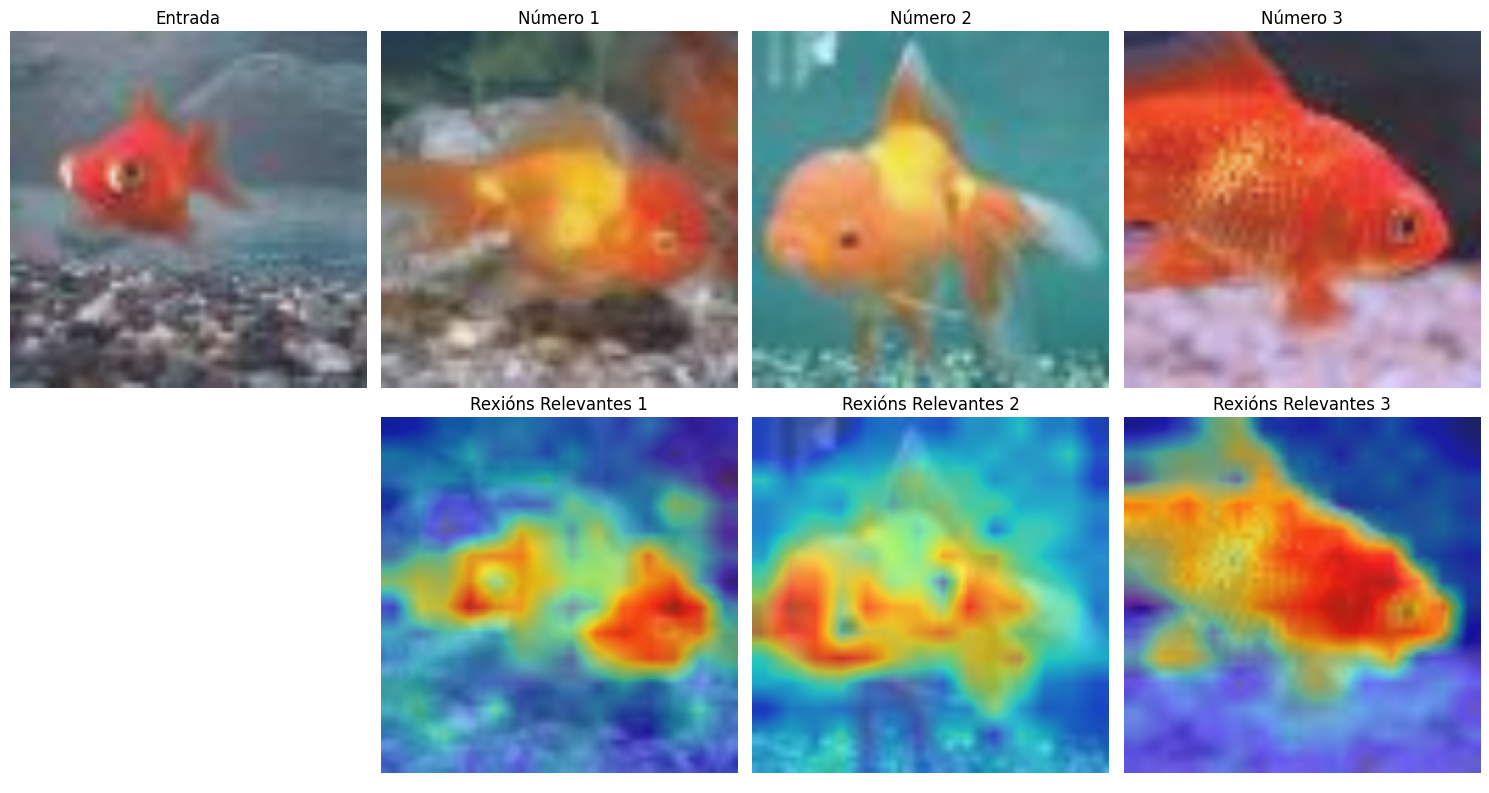

In [7]:
def mapa_similaridade(img_tensor_query, img_tensor_resultado, model):

    with torch.no_grad():
        # Características da Query (só o CLS)
        q_out = model(img_tensor_query.unsqueeze(0).to(device))
        q_cls = q_out.last_hidden_state[:, 0, :] # [1, 768]

        # Características do Resultado
        r_out = model(img_tensor_resultado.unsqueeze(0).to(device))
        r_patches = r_out.last_hidden_state[:, 1:, :] # [1, 196, 768] (sen o CLS)

        # Normalizamos
        q_cls = F.normalize(q_cls, p=2, dim=1)
        r_patches = F.normalize(r_patches, p=2, dim=2)

        # Calcular similitude coseno entre CLS da query e cada parche do resultado
        # [1, 768] x [768, 196] -> [1, 196]
        sim_map = torch.matmul(q_cls, r_patches.transpose(1, 2))

        # Redimensionar de volta ao grid de 14x14 (para vit-b16 en 224x224)
        sim_map = sim_map.view(14, 14).cpu().numpy()

        # Upsample para tamaño da imaxe (224x224)
        sim_map_resized = cv2.resize(sim_map, (224, 224))
        return sim_map_resized

def visualize_similarity(query_idx, feats, dataset, model, k=3):
    # Buscar resultados
    feats_query = feats[query_idx].unsqueeze(0)
    sims = torch.mm(feats_query, feats.t())
    sims[0, query_idx] = -1
    _, topk = torch.topk(sims, k)

    img_query = dataset[query_idx][0]

    _, eixos = plt.subplots(2, k+1, figsize=(15, 8))

    # Amosar Query
    q_img_display = img_query.permute(1,2,0).numpy() * 0.2 + 0.5
    eixos[0, 0].imshow(q_img_display)
    eixos[0, 0].set_title("Entrada")
    eixos[1, 0].axis('off')

    for i, res_idx in enumerate(topk[0]):
        res_img = dataset[res_idx][0]
        sim_map = mapa_similaridade(img_query, res_img, model)

        res_img_display = res_img.permute(1,2,0).numpy() * 0.2 + 0.5

        # Imaxe recuperada
        eixos[0, i+1].imshow(res_img_display)
        eixos[0, i+1].set_title(f"Número {i+1}")

        # Mapa de similaridade
        eixos[1, i+1].imshow(res_img_display)
        eixos[1, i+1].imshow(sim_map, cmap='jet_r', alpha=0.5)
        eixos[1, i+1].set_title(f"Rexións Relevantes {i+1}")

    for ax in eixos.ravel(): ax.axis('off')
    plt.tight_layout()
    plt.show()

print("\n\tMapas de similaridade:")
visualize_similarity(200, feats_dino, subset_dataset, model_dino, k=3)

  DINO presenta unha precisión lixeiramente inferior (78.3%) á do ViT supervisado (84.7%). Porén, ao observar os Mapas de Similaridade, vemos que DINO fócase moito máis no obxecto central e ignora mellor o fondo (a auga ou as rochas do acuario). Isto suxire que os seus embeddings son máis semánticos e menos dependentes de texturas globais ou cores do fondo.